---
tags: [algorithm, encoding, primitive]
---

# Möttönen Amplitude Encoding

**Amplitude encoding** is the operation that, given a unit-norm
complex vector $a \in \mathbb{C}^{2^n}$, prepares the $n$-qubit state

$$
|\psi\rangle \;=\; \sum_{i=0}^{2^n - 1} a_i \, |i\rangle
$$

starting from $|0\rangle^{\otimes n}$. It is the entry door for any
algorithm that consumes classical data as a quantum state — including
HHL-style linear-system solvers, kernel methods, and many quantum
simulation protocols. Qamomile ships a backend-portable implementation
under `qamomile.circuit.algorithm.state_preparation`, based on the
uniformly controlled rotation construction of Möttönen, Vartiainen,
Bergholm and Salomaa {cite:p}`10.48550/arXiv.quant-ph/0407010`.

The construction has two stages:

1. A cascade of $n$ **uniformly controlled $R_y$** gates that
   distributes the magnitude $|a_i|$ across the basis states. This
   stage alone is sufficient for real (signed) amplitude vectors.
2. A second cascade of **uniformly controlled $R_z$** gates that
   restores the relative phases. Only emitted when the input has a
   non-zero imaginary part.

Each uniformly controlled rotation is decomposed into elementary
`RY` / `RZ` and `CNOT` gates using the Gray-code recipe of
Möttönen-Vartiainen. The total cost is

| Stage | Real input | Complex input |
|---|---:|---:|
| $R_y$ rotations | $2^n - 1$ | $2^n - 1$ |
| $R_z$ rotations | $0$ | $2^n - 1$ |
| `CNOT` | $2^n - 2$ | $2 (2^n - 2)$ |

This tutorial walks through the public API surface, demonstrates each
entry point with a runnable example, and ends with a comparison table
you can use to decide which API to reach for in your own code.

In [1]:
import numpy as np
from qiskit.quantum_info import Statevector

import qamomile.circuit as qmc
import qamomile.observable as qm_o
from qamomile.circuit.algorithm import (
    MottonenAmplitudeEncoding,
    amplitude_encoding,
    amplitude_encoding_from_angles,
    compute_mottonen_amplitude_encoding_ry_angles,
    compute_mottonen_amplitude_encoding_rz_angles,
)
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()
executor = transpiler.executor()

# Tolerance used by every fidelity / probability check below.  Tight
# enough to catch any silent regression in the docs build, loose
# enough to absorb shot noise on sampler comparisons.
ATOL_STATEVECTOR = 1e-8
ATOL_SHOT = 0.05  # for 8192 shots, ~5σ on p(1-p)/N for any single bin


def fidelity(prepared: np.ndarray, target: np.ndarray) -> float:
    """Phase-invariant fidelity ``|<prepared|target>|^2``."""
    return float(np.abs(np.vdot(prepared, target)) ** 2)


def normalize(amps: list[float] | list[complex]) -> np.ndarray:
    """Unit-norm copy of *amps* (complex dtype if any element is complex)."""
    if any(isinstance(x, complex) for x in amps):
        arr = np.asarray(amps, dtype=complex)
    else:
        arr = np.asarray(amps, dtype=float)
    return arr / np.linalg.norm(arr)


def statevector_of(kernel: qmc.QKernel, **bindings) -> np.ndarray:
    """Run *kernel* through Qiskit's statevector simulator and return the data."""
    qc = transpiler.to_circuit(kernel, bindings=bindings or None)
    return Statevector.from_instruction(
        qc.remove_final_measurements(inplace=False)
    ).data

## 1. The simplest call — concrete real amplitudes

`amplitude_encoding(qubits, amplitudes)` is the everyday entry point.
It accepts a Python sequence or NumPy array, normalises it
automatically, and prepares the corresponding state.

As a first sanity check we encode the (un-normalised) vector
$a = (1, 2, 3, 4)$ on a 2-qubit register, read back the simulator's
statevector, and assert it matches the normalised target up to phase.

In [2]:
amps_real = [1.0, 2.0, 3.0, 4.0]


@qmc.qkernel
def prepare_real() -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(2, "q")
    q = amplitude_encoding(q, amps_real)
    return qmc.measure(q)


sv = statevector_of(prepare_real)
expected = normalize(amps_real)
print(f"prepared      = {np.round(sv, 4)}")
print(f"target (norm) = {np.round(expected, 4)}")
print(f"fidelity      = {fidelity(sv, expected):.6f}")
assert fidelity(sv, expected) == np.float64(1.0) or np.isclose(
    fidelity(sv, expected), 1.0, atol=ATOL_STATEVECTOR
), "real amplitude encoding lost fidelity"

prepared      = [0.1826+0.j 0.3651+0.j 0.5477+0.j 0.7303+0.j]
target (norm) = [0.1826 0.3651 0.5477 0.7303]
fidelity      = 1.000000


Negative real amplitudes flow through the magnitude stage naturally —
the leaf-level $R_y$ angle is taken as a signed `arctan2`, so the sign
is captured without an extra phase stage. The state $a = (1, -1, 1, -1)$
is therefore prepared with `RY` and `CNOT` only.

In [3]:
amps_signed = [1.0, -1.0, 1.0, -1.0]


@qmc.qkernel
def prepare_signed() -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(2, "q")
    q = amplitude_encoding(q, amps_signed)
    return qmc.measure(q)


sv = statevector_of(prepare_signed)
expected = normalize(amps_signed)
print(f"fidelity (signed) = {fidelity(sv, expected):.6f}")
assert np.isclose(fidelity(sv, expected), 1.0, atol=ATOL_STATEVECTOR), (
    "signed real encoding lost fidelity"
)

fidelity (signed) = 1.000000


## 2. Complex amplitudes

The same API accepts complex inputs. When at least one entry has a
non-zero imaginary part, the implementation switches to the two-stage
(Ry + Rz) construction automatically. A complex vector with
identically zero imaginary part is silently coerced to the cheaper
real path.

We encode $a = (1, 1+i, 1-i, 2i)$ — a generic complex 2-qubit state —
and assert the resulting statevector matches (up to global phase).

In [4]:
amps_complex = [1 + 0j, 1 + 1j, 1 - 1j, 0 + 2j]


@qmc.qkernel
def prepare_complex() -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(2, "q")
    q = amplitude_encoding(q, amps_complex)
    return qmc.measure(q)


sv = statevector_of(prepare_complex)
expected = normalize(amps_complex)
print(f"fidelity (complex) = {fidelity(sv, expected):.6f}")
assert np.isclose(fidelity(sv, expected), 1.0, atol=ATOL_STATEVECTOR), (
    "complex encoding lost fidelity"
)

fidelity (complex) = 1.000000


## 3. Visualisation and resource estimation

Once a kernel uses `amplitude_encoding`, the entire IR carries the
encoding as a single `MottonenAmplitudeEncoding` composite gate.  Two
Qamomile-side inspection APIs work out-of-the-box on it:

* `kernel.draw(fold_loops=False)` renders the IR.  We pass
  `fold_loops=False` so any `qmc.range` inside the gate's
  decomposition is unrolled in the diagram (the default `True`
  collapses each loop into a single block).
* `kernel.estimate_resources()` walks the IR and returns a
  `ResourceEstimate` with qubit count and gate breakdown — including
  the elementary RY / RZ / CNOT counts after the composite gate is
  resolved.  This is the supported way to check gate cost; it
  abstracts over the composite-gate machinery so user code never
  needs to look at `_resources().custom_metadata` directly.

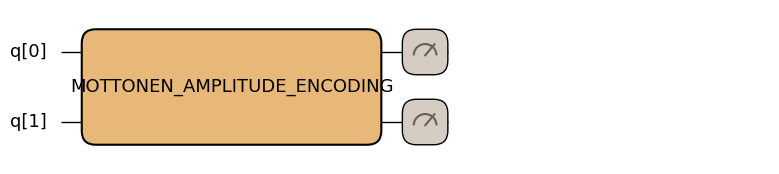

In [5]:
prepare_real.draw(fold_loops=False)

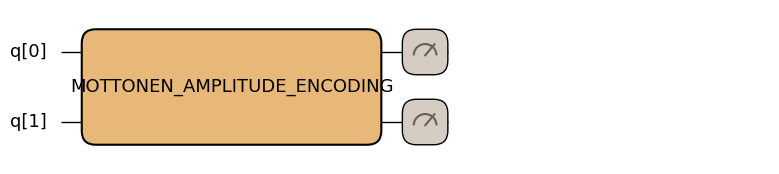

In [6]:
prepare_complex.draw(fold_loops=False)

In [7]:
est_real = prepare_real.estimate_resources()
est_complex = prepare_complex.estimate_resources()

print(
    f"real    : qubits={est_real.qubits}  total={est_real.gates.total}  "
    f"single={est_real.gates.single_qubit}  two={est_real.gates.two_qubit}  "
    f"rotations={est_real.gates.rotation_gates}  clifford={est_real.gates.clifford_gates}"
)
print(
    f"complex : qubits={est_complex.qubits}  total={est_complex.gates.total}  "
    f"single={est_complex.gates.single_qubit}  two={est_complex.gates.two_qubit}  "
    f"rotations={est_complex.gates.rotation_gates}  clifford={est_complex.gates.clifford_gates}"
)

# Closed-form reference (n = 2 qubits):
#   real    Ry: 2^n - 1 = 3,  CNOT: 2^n - 2 = 2,  total = 5
#   complex Ry: 3,  Rz: 3,  CNOT: 2 * (2^n - 2) = 4,  total = 10
assert int(est_real.qubits) == 2
assert int(est_real.gates.total) == 5
assert int(est_real.gates.rotation_gates) == 3
assert int(est_real.gates.two_qubit) == 2
assert int(est_complex.qubits) == 2
assert int(est_complex.gates.total) == 10
assert int(est_complex.gates.rotation_gates) == 6
assert int(est_complex.gates.two_qubit) == 4

real    : qubits=2  total=5  single=3  two=2  rotations=3  clifford=2
complex : qubits=2  total=10  single=6  two=4  rotations=6  clifford=4


Both counts grow as $O(2^n)$: amplitude encoding is intrinsically
expensive for many qubits.  In practice this construction is most
useful at the small register sizes one encounters as a building block
inside larger algorithms (HHL with 4–8 logical qubits in the input
register, QSCI with a sampled subspace, error-correction warm-starts,
etc.), not as a stand-alone preparation for hundreds of qubits.

## 4. Public API surface — when to reach for which entry point

The state-preparation package exposes five public names. The table
below summarises which one to use for which job, and the trade-off
each makes.

| API | Use it when | Pros | Cons |
|---|---|---|---|
| `amplitude_encoding(q, amplitudes)` (concrete sequence) | The amplitudes are known where you build the kernel, e.g. as a Python list / numpy array in the surrounding scope. | Simplest call site. IR keeps a single `MottonenAmplitudeEncoding` composite gate, so resource estimation and future native dispatch (e.g. Qiskit `StatePreparation` via a `CompositeGateEmitter`) stay open. | Each new amplitude vector needs a fresh `transpile()` call. |
| `amplitude_encoding(q, amps)` + `bindings={"amps": [...]}` | You'd rather expose `amps: Vector[Float]` as a kernel parameter (for documentation, sweeping, or to keep the kernel free of magic numbers), but the values are still resolved at compile time. | Same IR shape and merits as the concrete-sequence form; no need to pre-compute Möttönen angles. The implementation reads the bound concrete data at trace time via `amps.value.get_const_array()`. | Real-only (a `Vector[Float]` cannot carry complex values). `parameters=["amps"]` is rejected by design — see the angles-based runtime path below. |
| `amplitude_encoding_from_angles(q, ry_angles, rz_angles=None)` + `bindings={...}` | You have already pre-computed Möttönen angles (e.g. shared across multiple kernels) and want to bind them at compile time. | Compile-time bound, same recompile-per-vector cost as the routes above; works for both real (rz_angles=None) and complex inputs. | Skips the `MottonenAmplitudeEncoding` composite-gate wrapping and emits the elementary `RY` / `RZ` / `CNOT` gates directly into the IR — resource estimation sees the elementary gates rather than the high-level op. |
| `amplitude_encoding_from_angles(q, ry_a, rz_a)` + `parameters=[...]` | You need the **same compiled circuit** to be re-bound to many amplitude vectors at run time (hybrid optimisation loops, parameter sweeps). | Compile once, sample many times via `executable.sample(bindings={...})` — the dominant cost is no longer recompilation. The only path that supports runtime-symbolic angles. | The user (your code) must call `compute_mottonen_amplitude_encoding_*_angles(...)` per iteration to translate amplitudes → angles. Same flat-IR caveat as the bindings form. |
| `MottonenAmplitudeEncoding(amplitudes)` (class) | You want the composite gate as a first-class object — typically for resource estimation outside a kernel, or to plug into a custom decomposition strategy. | Direct access to `gate.num_target_qubits` and the IR-side composite-gate object. | Most user code is better served by `amplitude_encoding`, which wraps the construction. |
| `compute_mottonen_amplitude_encoding_ry_angles(amps)` / `compute_mottonen_amplitude_encoding_rz_angles(amps)` | You need the Gray-walk Ry / Rz angles classically — to feed the runtime-parametric path above, to cache across kernels, or to reason about the angle values directly. | Fast pure-Python / NumPy preprocessing; keeps the angle computation outside the kernel build. Real inputs always return all-zeros from the Rz helper. | Requires understanding that the returned arrays already include the bit-reverse + $M^{(k)}$ Gray-walk transform — they are not the raw per-control-state angles. |

The next two cells exercise the two non-trivial bindings/parameters
entry points so you can see them in action.

### `amplitude_encoding` with a bound `Vector[Float]` parameter

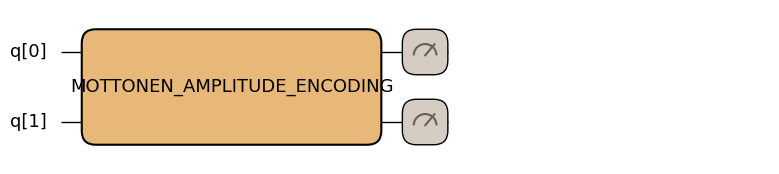

In [8]:
@qmc.qkernel
def prepare_via_binding(amps: qmc.Vector[qmc.Float]) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(2, "q")
    q = amplitude_encoding(q, amps)
    return qmc.measure(q)


prepare_via_binding.draw(fold_loops=False, amps=[1.0, 2.0, 3.0, 4.0])

In [9]:
sv = statevector_of(prepare_via_binding, amps=[1.0, 2.0, 3.0, 4.0])
print(
    f"fidelity (bound Vector[Float]) = {fidelity(sv, normalize([1.0, 2.0, 3.0, 4.0])):.6f}"
)
assert np.isclose(
    fidelity(sv, normalize([1.0, 2.0, 3.0, 4.0])), 1.0, atol=ATOL_STATEVECTOR
)

fidelity (bound Vector[Float]) = 1.000000


Trying to leave that parameter symbolic with `parameters=["amps"]`
is rejected with a directing error — the angle computation
(`atan2(|a_1|, |a_0|)` and friends) needs concrete numbers and
therefore fundamentally cannot be deferred to runtime.  The error
points at `amplitude_encoding_from_angles` for the runtime case.

In [10]:
try:
    transpiler.transpile(prepare_via_binding, parameters=["amps"])
except ValueError as exc:
    print(f"ValueError: {exc}")
    raised = True
else:
    raised = False
assert raised, "expected ValueError when amps is a runtime parameter"

ValueError: amplitude_encoding received a Vector[Float] handle without concrete values at trace time. Bind it via transpiler.transpile(kernel, bindings={...}) for compile-time amplitudes, or use amplitude_encoding_from_angles with parameters=[...] for runtime-parametric angles.


### Runtime-parametric angles — compile once, re-bind many times

`amplitude_encoding_from_angles` is the only path that lets us reuse
a single compiled circuit across different amplitude vectors at run
time.  Pre-compute the angles classically with the
`compute_mottonen_amplitude_encoding_*_angles` helpers, transpile
once with `parameters=[...]`, then sample with new bindings each
iteration.

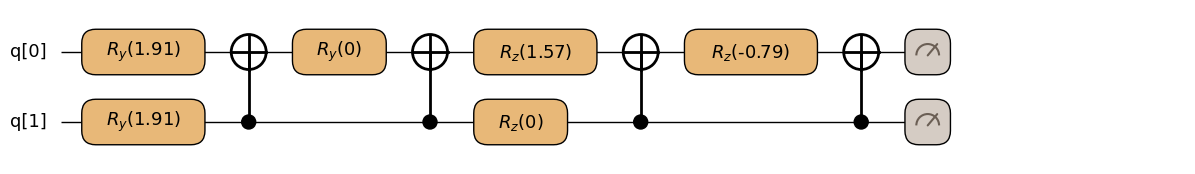

In [11]:
@qmc.qkernel
def prepare_from_angles(
    ry_a: qmc.Vector[qmc.Float], rz_a: qmc.Vector[qmc.Float]
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(2, "q")
    q = amplitude_encoding_from_angles(q, ry_a, rz_a)
    return qmc.measure(q)


prepare_from_angles.draw(
    fold_loops=False,
    ry_a=compute_mottonen_amplitude_encoding_ry_angles(amps_complex).tolist(),
    rz_a=compute_mottonen_amplitude_encoding_rz_angles(amps_complex).tolist(),
)

In [12]:
exe = transpiler.transpile(prepare_from_angles, parameters=["ry_a", "rz_a"])
n_runtime_params = len(exe.compiled_quantum[0].circuit.parameters)
print(f"runtime parameters in compiled circuit: {n_runtime_params}")
assert n_runtime_params == 2 * (2**2 - 1), (
    "expected 2 * (2^n - 1) parametric rotations for n=2 complex"
)

shots = 8192
for trial_amps in (
    [1.0, 0.0, 0.0, 1.0],
    [3.0, 4.0, 0.0, 0.0],
    [1 + 0j, 1j, -1 + 0j, -1j],
):
    ry = compute_mottonen_amplitude_encoding_ry_angles(trial_amps).tolist()
    rz = compute_mottonen_amplitude_encoding_rz_angles(trial_amps).tolist()
    counts = (
        exe.sample(executor, shots=shots, bindings={"ry_a": ry, "rz_a": rz})
        .result()
        .results
    )
    observed = np.zeros(4)
    for bits, c in counts:
        idx = sum(int(b) << i for i, b in enumerate(bits))
        observed[idx] = c / shots
    expected_probs = np.abs(normalize(trial_amps)) ** 2
    max_dev = float(np.max(np.abs(observed - expected_probs)))
    print(f"amps={str(trial_amps):<48s}  max|p_obs - p_exp| = {max_dev:.4f}")
    assert max_dev < ATOL_SHOT, (
        f"runtime-parametric sampling diverged for amps={trial_amps}"
    )

runtime parameters in compiled circuit: 6
amps=[1.0, 0.0, 0.0, 1.0]                              max|p_obs - p_exp| = 0.0089
amps=[3.0, 4.0, 0.0, 0.0]                              max|p_obs - p_exp| = 0.0022
amps=[(1+0j), 1j, (-1+0j), (-0-1j)]                    max|p_obs - p_exp| = 0.0031


All three iterations sample from the same compiled circuit; only the
runtime bindings change. The maximum per-bin deviation stays within
shot-noise tolerance.

## 5. Plugging into a larger kernel — observable estimation

`amplitude_encoding` is a building block — most users plug it into a
larger kernel.  The simplest such use case is computing
$\langle \psi | H | \psi \rangle$ for some Hamiltonian $H$ on the
prepared state.  The kernel becomes a single `expval`, and the
observable can be passed in as a runtime binding.

As a small analytic check, the encoded state for $a = (1, 2, 3, 4)$
(little-endian, qubit $0$ = LSB) gives

$$
  \langle Z_0 \rangle
  = (p_{00} + p_{10}) - (p_{01} + p_{11})
  = \frac{1 + 9 - 4 - 16}{30}
  = -\tfrac{1}{3},
$$

which we now reproduce with the estimator path.

In [13]:
@qmc.qkernel
def expval_kernel(H: qmc.Observable) -> qmc.Float:
    q = qmc.qubit_array(2, "q")
    q = amplitude_encoding(q, [1.0, 2.0, 3.0, 4.0])
    return qmc.expval(q, H)


H = qm_o.Z(0) + 0.0 * qm_o.Z(1)  # pad to 2-qubit width
exe_expval = transpiler.transpile(expval_kernel, bindings={"H": H})
result = exe_expval.run(executor).result()
print(f"<Z_0> = {float(result):+.6f}   (analytic: {-1 / 3:+.6f})")
assert np.isclose(float(result), -1.0 / 3.0, atol=1e-8), (
    "<Z_0> estimator deviated from analytic value"
)

<Z_0> = -0.333333   (analytic: -0.333333)
